# Capstone Project: RESTART

- **ID Tim Capstone:** CC26-PSU377
- **Tema:** Future-Ready Work & Economy
- **Anggota (Data Science):**
  1. Muhammad Aris Maulana (CDCC200D6Y0414)
  2. Maretta Govani Dinda Sacinta (CDCC200D6X0752)

**Tautan Penting Proyek:**
*  **Dashboard Interaktif (Streamlit):** [https://restart-dashboard.streamlit.app/](https://restart-dashboard.streamlit.app/)
*  **Repositori GitHub:** [https://github.com/Restar-ai/Restart.git](https://github.com/Restar-ai/Restart.git)

## Informasi Dataset (Data Provenance)

**Sumber Data Asli:**
O*NET Database (Occupational Information Network) yang dikelola oleh Departemen Tenaga Kerja Amerika Serikat. (Tautan: [O*NET Database](https://www.onetcenter.org/database.html))

**Deskripsi:**
Dataset ini berisi pemetaan standar internasional dari O*NET yang mencakup tiga dimensi utama untuk memprofilkan target profesi secara komprehensif. Pemilihan kombinasi ketiga dimensi pengukuran ini dirancang untuk membangun parameter asesmen yang multidimensional bagi mantan narapidana, dengan rincian sebagai berikut:

* **Kemampuan Fisik dan Kognitif (*Abilities*):** Berfungsi sebagai tolok ukur kapasitas dasar atau bawaan pengguna. Metrik ini sangat krusial untuk memastikan pengguna memiliki daya tahan dan ketangkasan fisik yang memadai guna menunjang profesi di sektor operasional.
* **Keahlian Teknis (*Skills*):** Berperan sebagai indikator kesiapan kerja praktis. Dimensi ini memetakan keahlian (seperti komunikasi dan pelayanan) yang dapat dilatih dan dikembangkan secara langsung oleh pengguna untuk memenuhi kebutuhan dunia kerja saat ini.
* **Preferensi Kepribadian Karir (*Interests* / Holland Code RIASEC):** Bertindak sebagai parameter kecocokan budaya kerja (*culture fit*). Mengukur preferensi ini sangat penting agar rekomendasi profesi sejalan dengan minat intrinsik pengguna, sehingga memperbesar peluang retensi dan kenyamanan di tempat kerja.

> *Kombinasi ketiga dimensi data di atas memastikan bahwa rekomendasi dari model Machine Learning RESTART tidak hanya mempertimbangkan apakah pengguna **mampu** melakukan suatu pekerjaan, tetapi juga apakah mereka akan **nyaman** melakukannya. Pendekatan holistik ini diharapkan mampu menekan risiko kegagalan adaptasi pasca-reintegrasi.*

**Modifikasi & Preprocessing:**
Data mentah dari O*NET telah difilter secara spesifik untuk belasan profesi yang relevan dengan ekosistem aplikasi RESTART (sektor UMKM, operasional, dan digital kreatif). Dataset kemudian diekspansi menjadi **2.400 baris sampel sintetik** melalui injeksi variansi distribusi statistik. Langkah ini dilakukan untuk mensimulasikan respons *user* secara natural guna kebutuhan pelatihan model agar terhindar dari *overfitting*.

## **Menentukan Pertanyaan Bisnis**

1. Bagaimana karakteristik dan distribusi 6 dimensi kepribadian Holland Code (RIASEC) dalam memetakan kecocokan karir pada target profesi di sektor UMKM, operasional, dan digital kreatif?
   
2. Dari 10 metrik kompetensi (fisik, komunikasi, dan kognitif) yang diekstraksi, kompetensi apa saja yang paling dominan secara lintas sektoral sehingga krusial untuk dijadikan parameter utama dalam kuesioner asesmen RESTART?

##**Importing Packages/Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

##**Data Wrangling**

###**Gathering Data**

In [2]:
# LOAD DATA ASLI O*NET
df_ab = pd.read_csv("Abilities.csv", sep=";", decimal=",")
df_sk = pd.read_csv("Skills.csv", sep=";", decimal=",")
df_in = pd.read_csv("Interests.csv", sep=";", decimal=",")

# Ambil nilai 'Importance' untuk Skills & Abilities, dan 'Occupational Interests' untuk Kepribadian
df_ab_imp = df_ab[df_ab['Scale Name'] == 'Importance'][['Title', 'Element Name', 'Data Value']]
df_sk_imp = df_sk[df_sk['Scale Name'] == 'Importance'][['Title', 'Element Name', 'Data Value']]
df_in_oi = df_in[df_in['Scale Name'] == 'Occupational Interests'][['Title', 'Element Name', 'Data Value']]

# Gabungkan semuanya
df_combined = pd.concat([df_ab_imp, df_sk_imp, df_in_oi], ignore_index=True)
df_combined['Data Value'] = pd.to_numeric(df_combined['Data Value'], errors='coerce')

# FILTER PEKERJAAN YANG RELEVAN (Sesuai Kursus & UMKM)
kamus_profesi = {
    "Copywriters": "Copywriter",
    "Graphic Designers": "Desainer Grafis",
    "Film and Video Editors": "Video Editor",
    "Photographers": "Fotografer",
    "Public Relations Specialists": "Admin Media Sosial",
    "Search Marketing Strategists": "Digital Marketer",
    "Demonstrators and Product Promoters": "Host Live Streamer",
    "Sales Representatives, Services, All Other": "Affiliate Marketer",
    "Media and Communication Workers": "Content Creator",
    "Web Developers": "Web Developer",
    "Data Entry Keyers": "Admin Data",
    "Baristas": "Barista",
    "Waiters and Waitresses": "Pramusaji",
    "Cashiers": "Kasir",
    "Customer Service Representatives": "Customer Service"
}

# Saring data hanya untuk pekerjaan di atas
df_filtered = df_combined[df_combined['Title'].isin(kamus_profesi.keys())].copy()

# PIVOT DATA (Dari Memanjang jadi Melebar)
df_pivot = df_filtered.pivot_table(
    index='Title', columns='Element Name', values='Data Value', aggfunc='first'
).reset_index()

# Tambahkan kolom nama Indonesia
df_pivot['Profesi_Indonesia'] = df_pivot['Title'].map(kamus_profesi)

# BUAT DATA LATIH UNTUK TIM AI (MULTIPLIKASI BARIS)
jumlah_data_per_profesi = 200
data_latih_ai = []

# Ambil nama-nama fitur (93 keahlian)
kolom_fitur = [c for c in df_pivot.columns if c not in ['Title', 'Profesi_Indonesia']]

for _, row in df_pivot.iterrows():
    profesi = row['Profesi_Indonesia']

    for _ in range(jumlah_data_per_profesi):
        baris_baru = {'Target_Profesi': profesi}

        for col in kolom_fitur:
            batas_atas = 7.0 if col in ['Realistic','Investigative','Artistic','Social','Enterprising','Conventional'] else 5.0
            nilai_asli = float(row[col]) if pd.notna(row[col]) else 2.5

            # Tambahkan variasi (variance) statistik agar tidak copy-paste identik
            noise = np.random.normal(0, 0.4)
            nilai_akhir = round(max(1.0, min(batas_atas, nilai_asli + noise)), 2)

            baris_baru[col] = nilai_akhir

        data_latih_ai.append(baris_baru)

df_final = pd.DataFrame(data_latih_ai)

df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total Jenis Pekerjaan: {len(kamus_profesi)} Profesi Relevan")
print(f"Total Data Baris: {len(df_final)} Baris")
df_final.head()

Total Jenis Pekerjaan: 15 Profesi Relevan
Total Data Baris: 2400 Baris


,Target_Profesi,Active Learning,Active Listening,Arm-Hand Steadiness,Artistic,Auditory Attention,Category Flexibility,Complex Problem Solving,Control Precision,Conventional,...,Time Management,Time Sharing,Troubleshooting,Trunk Strength,Visual Color Discrimination,Visualization,Wrist-Finger Speed,Writing,Written Comprehension,Written Expression
0,Pramusaji,2.25,2.98,2.95,1.56,2.57,2.02,3.08,2.82,4.73,...,2.90,3.17,1.71,3.20,2.33,1.37,1.19,2.70,1.93,2.44
1,Digital Marketer,3.98,3.90,1.17,2.70,1.95,3.91,3.49,1.31,4.54,...,3.05,2.90,1.27,1.00,2.20,1.95,1.00,4.00,3.41,4.50
2,Host Live Streamer,2.97,3.36,1.59,3.47,2.72,3.00,3.25,1.99,3.85,...,3.81,2.51,1.50,3.51,2.93,3.22,2.11,3.90,3.07,2.61
3,Admin Media Sosial,3.08,3.26,1.00,4.69,1.63,2.97,2.53,1.44,2.98,...,4.38,2.75,1.00,1.67,2.39,2.65,1.01,3.84,3.29,4.20
4,Pramusaji,2.91,2.83,3.34,1.89,1.95,2.68,1.78,2.31,4.35,...,2.77,3.24,1.54,3.63,2.39,2.20,1.12,2.52,3.09,2.46


Nilai simpangan baku (standard deviation) sebesar 0.4 dipilih secara sengaja untuk menciptakan variasi respons pengguna yang natural, namun tidak terlalu ekstrem hingga merusak profil asli dari profesi tersebut (mengingat rentang skala kompetensi hanya 1-5 dan RIASEC 1-7).

**Insight:**
- Dataset asli dari O*NET berhasil digabungkan (*Abilities*, *Skills*, *Interests*) dan disaring secara spesifik hanya untuk 15 target profesi aplikasi RESTART (sektor UMKM, Operasional, dan Digital Kreatif).
- Telah dilakukan transformasi bentuk data (*Pivot*) sehingga setiap profesi kini memiliki representasi nilai fiturnya masing-masing dalam satu baris.
- **Data Generation:** Dataset awal berhasil diekspansi menjadi **2.400 baris** (kurang lebih 160 sampel per profesi) dengan menyuntikkan variansi statistik (*noise* distribusi normal). Langkah augmentasi ini sangat krusial agar dataset yang akan digunakan untuk melatih model *Machine Learning* memiliki variasi yang natural dan mencegah terjadinya *overfitting*.

###**Assessing Data**

In [3]:
print("===== INFORMASI DATA =====")
print(df_final.info())

print("\n===== 5 DATA TERATAS =====")
print(df_final.head())

print("\n===== UKURAN DATA =====")
print(f"Jumlah Baris : {df_final.shape[0]}")
print(f"Jumlah Kolom : {df_final.shape[1]}")

print("\n===== CEK MISSING VALUES =====")
print(df_final.isnull().sum())

print("\n===== CEK DUPLIKAT =====")
print(f"Jumlah data duplikat: {df_final.duplicated().sum()}")

print("\n===== STATISTIK DESKRIPTIF =====")
print(df_final.describe())

===== INFORMASI DATA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 94 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Target_Profesi                     2400 non-null   object 
 1   Active Learning                    2400 non-null   float64
 2   Active Listening                   2400 non-null   float64
 3   Arm-Hand Steadiness                2400 non-null   float64
 4   Artistic                           2400 non-null   float64
 5   Auditory Attention                 2400 non-null   float64
 6   Category Flexibility               2400 non-null   float64
 7   Complex Problem Solving            2400 non-null   float64
 8   Control Precision                  2400 non-null   float64
 9   Conventional                       2400 non-null   float64
 10  Coordination                       2400 non-null   float64
 11  Critical Thinking            

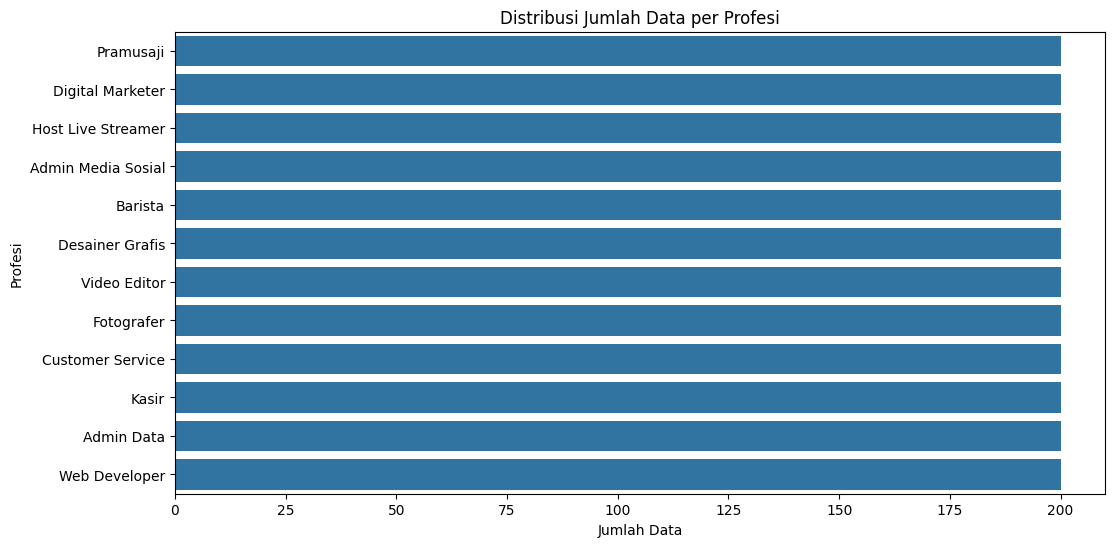

In [4]:
# VISUALISASI DISTRIBUSI PROFESI
plt.figure(figsize=(12,6))
sns.countplot(
    y='Target_Profesi',
    data=df_final,
    order=df_final['Target_Profesi'].value_counts().index
)

plt.title("Distribusi Jumlah Data per Profesi")
plt.xlabel("Jumlah Data")
plt.ylabel("Profesi")
plt.show()

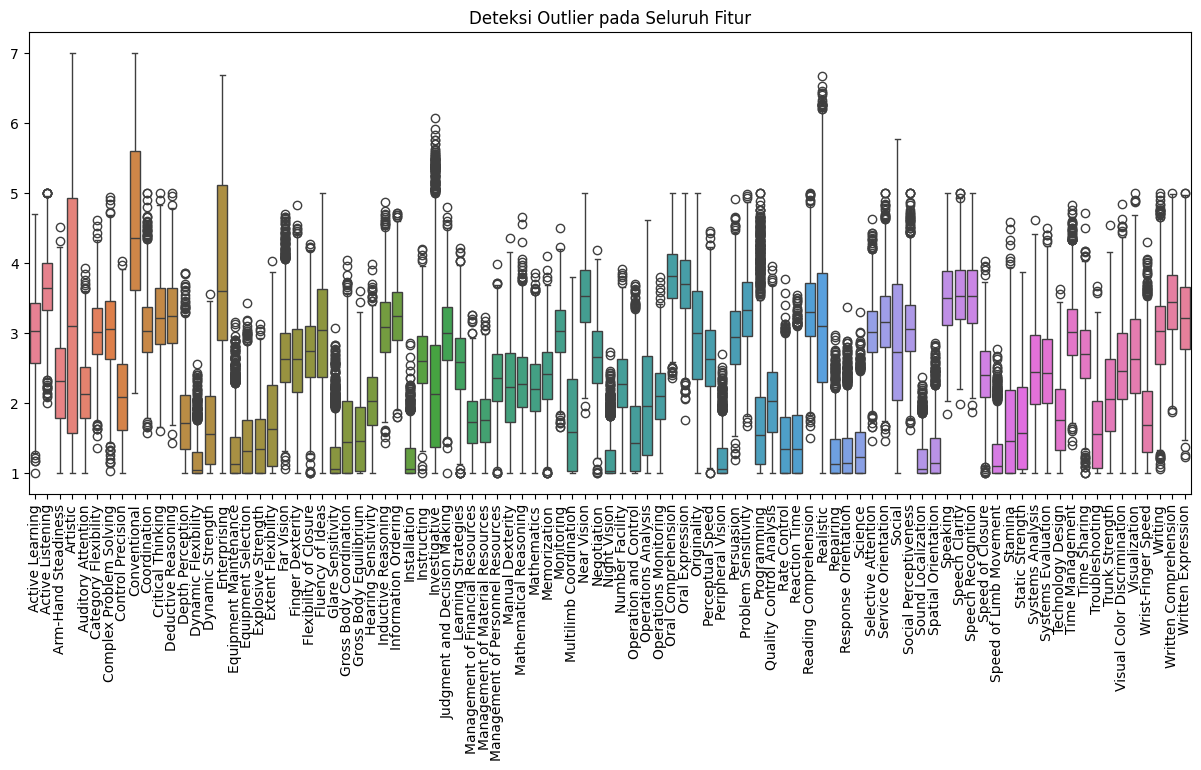

In [5]:
# CEK OUTLIER DENGAN BOXPLOT
plt.figure(figsize=(15,6))
sns.boxplot(data=df_final[kolom_fitur])

plt.xticks(rotation=90)
plt.title("Deteksi Outlier pada Seluruh Fitur")
plt.show()

**Tujuan:**

Bertujuan memeriksa kualitas dataset sebelum dilakukan proses cleaning dan feature selection, guna memastikan bahwa data memiliki struktur yang benar, memiliki tipe data yang sesuai, memiliki distribusi target yang seimbang, dan tidak memiliki nilai ekstrem yang tidak valid.

**Insight:**
- Dataset mentah memiliki dimensi yang sangat besar, yaitu **2.400 baris dan 94 kolom** (1 target profesi + 93 fitur).
- **Kelengkapan Data:** Dataset sangat bersih pada tahap awal ini; tidak terdeteksi adanya nilai kosong (*missing values*) maupun baris yang terduplikasi secara identik.
- **Distribusi Target:** Berdasarkan visualisasi `countplot`, distribusi jumlah sampel data per kategori profesi sudah seimbang (*balanced dataset*), yang mana ini merupakan syarat ideal untuk klasifikasi AI.
- **Deteksi Outlier:** Visualisasi `boxplot` menunjukkan adanya sebaran data yang bervariasi akibat penambahan *noise*. Beberapa nilai mungkin sedikit melewati batas maksimum skala psikometri, sehingga diperlukan validasi rentang (*clipping*) pada tahap *cleaning* selanjutnya.

##**Cleaning Data**

In [6]:
# HAPUS DATA DUPLIKAT
df_final = df_final.drop_duplicates()

print("Jumlah data setelah hapus duplikat:")
print(df_final.shape)

# HANDLE MISSING VALUES
for col in kolom_fitur:
    df_final[col] = df_final[col].fillna(df_final[col].mean())

print("\nMissing values setelah cleaning:")
print(df_final.isnull().sum().sum())

# VALIDASI RENTANG NILAI
for col in kolom_fitur:
    # Interest scale maksimum 7
    if col in ['Realistic','Investigative','Artistic',
               'Social','Enterprising','Conventional']:
        df_final[col] = df_final[col].clip(1,7)
    # Skill & Ability maksimum 5
    else:
        df_final[col] = df_final[col].clip(1,5)

print("\nValidasi rentang nilai selesai!")

# CEK TIPE DATA
print("\n===== TIPE DATA =====")
print(df_final.dtypes)

Jumlah data setelah hapus duplikat:
(2400, 94)

Missing values setelah cleaning:
0

Validasi rentang nilai selesai!

===== TIPE DATA =====
Target_Profesi            object
Active Learning          float64
Active Listening         float64
Arm-Hand Steadiness      float64
Artistic                 float64
                          ...   
Visualization            float64
Wrist-Finger Speed       float64
Writing                  float64
Written Comprehension    float64
Written Expression       float64
Length: 94, dtype: object


**Tujuan:**

Memperbaiki dan memastikan dataset berada dalam kondisi bersih, valid, dan siap digunakan untuk analisis maupun modeling.

**Insight:**

- Dataset telah melalui proses penghapusan duplikasi, dan hasilnya jumlah data tetap **2.400 baris**, sehingga dapat disimpulkan bahwa tidak terdapat data duplikat yang memengaruhi kualitas dataset.
- Setelah proses penanganan missing values, jumlah nilai kosong adalah **0**, yang menunjukkan bahwa dataset sudah lengkap dan tidak membutuhkan imputasi lanjutan.
- Seluruh nilai fitur telah divalidasi menggunakan metode **clipping** agar tetap berada pada skala yang valid. Fitur RIASEC dikunci pada rentang **1.0–7.0**, sedangkan fitur kompetensi, skills, dan abilities dikunci pada rentang **1.0–5.0**.
- Validasi rentang nilai penting karena dataset sebelumnya dibuat dengan penambahan noise statistik, sehingga ada kemungkinan nilai keluar dari batas skala asli.
- Tipe data sudah sesuai, yaitu `Target_Profesi` sebagai variabel kategorikal dan fitur lainnya sebagai variabel numerik.
- Setelah cleaning, dataset siap memasuki tahap feature selection dan modeling karena sudah bersih, valid, dan konsisten.

##**Feature Selection**

In [7]:
# Daftar fitur yang akan diubah menjadi kuesioner aplikasi
fitur_16 = [
    'Stamina', 'Static Strength', 'Manual Dexterity', 'Spatial Orientation',
    'Active Listening', 'Speaking', 'Service Orientation', 'Coordination',
    'Troubleshooting', 'Time Management',
    'Realistic', 'Investigative', 'Artistic', 'Social', 'Enterprising', 'Conventional'
]

# Memotong dataframe, hanya menyisakan profesi dan 16 fitur
df_clean = df_final[['Target_Profesi'] + fitur_16]

print("Dimensi data setelah Feature Selection:")
print(df_clean.shape) # Outputnya nanti akan menjadi (Jumlah Baris, 16 Kolom)

df_clean.head()

Dimensi data setelah Feature Selection:
(2400, 17)


,Target_Profesi,Stamina,Static Strength,Manual Dexterity,Spatial Orientation,Active Listening,Speaking,Service Orientation,Coordination,Troubleshooting,Time Management,Realistic,Investigative,Artistic,Social,Enterprising,Conventional
0,Pramusaji,3.48,3.44,2.68,1.62,2.98,2.92,3.85,3.35,1.71,2.90,4.71,1.00,1.56,5.13,4.02,4.73
1,Digital Marketer,1.11,1.21,1.00,1.00,3.90,3.95,2.52,3.30,1.27,3.05,1.00,4.09,2.70,2.17,4.97,4.54
2,Host Live Streamer,1.78,2.23,1.74,1.66,3.36,4.52,3.15,2.91,1.50,3.81,3.62,2.52,3.47,3.54,5.23,3.85
3,Admin Media Sosial,1.00,1.34,1.07,1.46,3.26,4.32,3.47,4.19,1.00,4.38,1.20,2.45,4.69,3.87,5.66,2.98
4,Pramusaji,2.91,2.69,2.55,1.93,2.83,3.37,3.55,2.36,1.54,2.77,4.02,1.36,1.89,4.93,3.99,4.35


**Tujuan:**

Memilih fitur yang paling relevan untuk digunakan dalam sistem asesmen RESTART. Feature selection dilakukan agar kuesioner aplikasi tidak terlalu panjang, tetapi tetap mampu merepresentasikan profil pengguna secara cukup baik.

**Insight:**
*   Dari 93 fitur awal, dipilih 16 fitur utama yang terdiri dari 10 fitur kompetensi dan 6 fitur kepribadian RIASEC.
*   Fitur dipilih karena dianggap paling relevan dengan kebutuhan aplikasi RESTART. Sepuluh fitur kompetensi mewakili kemampuan fisik, komunikasi, pelayanan, koordinasi, problem solving, dan manajemen waktu. Sementara itu, enam fitur RIASEC digunakan untuk memahami kecenderungan minat dan karakteristik karier pengguna.
*  Hasil akhir feature selection adalah dataset `df_clean` dengan 2400 baris, 17 kolom (1 kolom target profesi & 16 kolom fitur asesmen).

In [8]:
# EXPORT DATA CLEAN
df_clean.to_csv("Master_Data_RESTART.csv",
                index=False,
                sep=";")

Dataset final `Master_Data_RESTART.csv` yang berisi 2.400 baris dan 16 fitur prediktor ini telah bersih, tervalidasi rentang skalanya, dan seimbang secara kelas. Dataset ini secara resmi diserahkan kepada tim AI Engineer sebagai *ground truth* untuk melatih arsitektur pemodelan *Deep Neural Network* (DNN).

##**Exploratory Data Analysis (EDA)**

In [9]:
# Pisahkan kolom untuk mempermudah analisis
kolom_riasec = ['Realistic', 'Investigative', 'Artistic', 'Social', 'Enterprising', 'Conventional']
kolom_kompetensi = ['Stamina', 'Static Strength', 'Manual Dexterity', 'Spatial Orientation',
                    'Active Listening', 'Speaking', 'Service Orientation', 'Coordination',
                    'Troubleshooting', 'Time Management']

print("=== 1. RATA-RATA KEPRIBADIAN (RIASEC) PER PROFESI ===")
df_riasec_mean = df_clean.groupby('Target_Profesi')[kolom_riasec].mean().round(2)
display(df_riasec_mean.head())

print("\n=== 2. TOP 5 KOMPETENSI PALING DIBUTUHKAN LINTAS PROFESI ===")
top_kompetensi = df_clean[kolom_kompetensi].mean().sort_values(ascending=False).round(2)
display(pd.DataFrame({'Rata-rata Skor (Max 5.0)': top_kompetensi}).head(5))

=== 1. RATA-RATA KEPRIBADIAN (RIASEC) PER PROFESI ===


,Realistic,Investigative,Artistic,Social,Enterprising,Conventional
Target_Profesi,,,,,,
Admin Data,3.05,2.29,1.17,1.29,1.70,6.84
Admin Media Sosial,1.15,2.72,4.69,3.94,5.84,3.43
Barista,5.57,1.19,2.64,3.73,3.26,3.67
Customer Service,1.95,1.65,1.17,3.76,5.09,6.32
Desainer Grafis,3.37,2.83,6.86,2.17,3.43,3.90



=== 2. TOP 5 KOMPETENSI PALING DIBUTUHKAN LINTAS PROFESI ===


,Rata-rata Skor (Max 5.0)
Active Listening,3.65
Speaking,3.49
Service Orientation,3.18
Coordination,3.06
Time Management,3.03


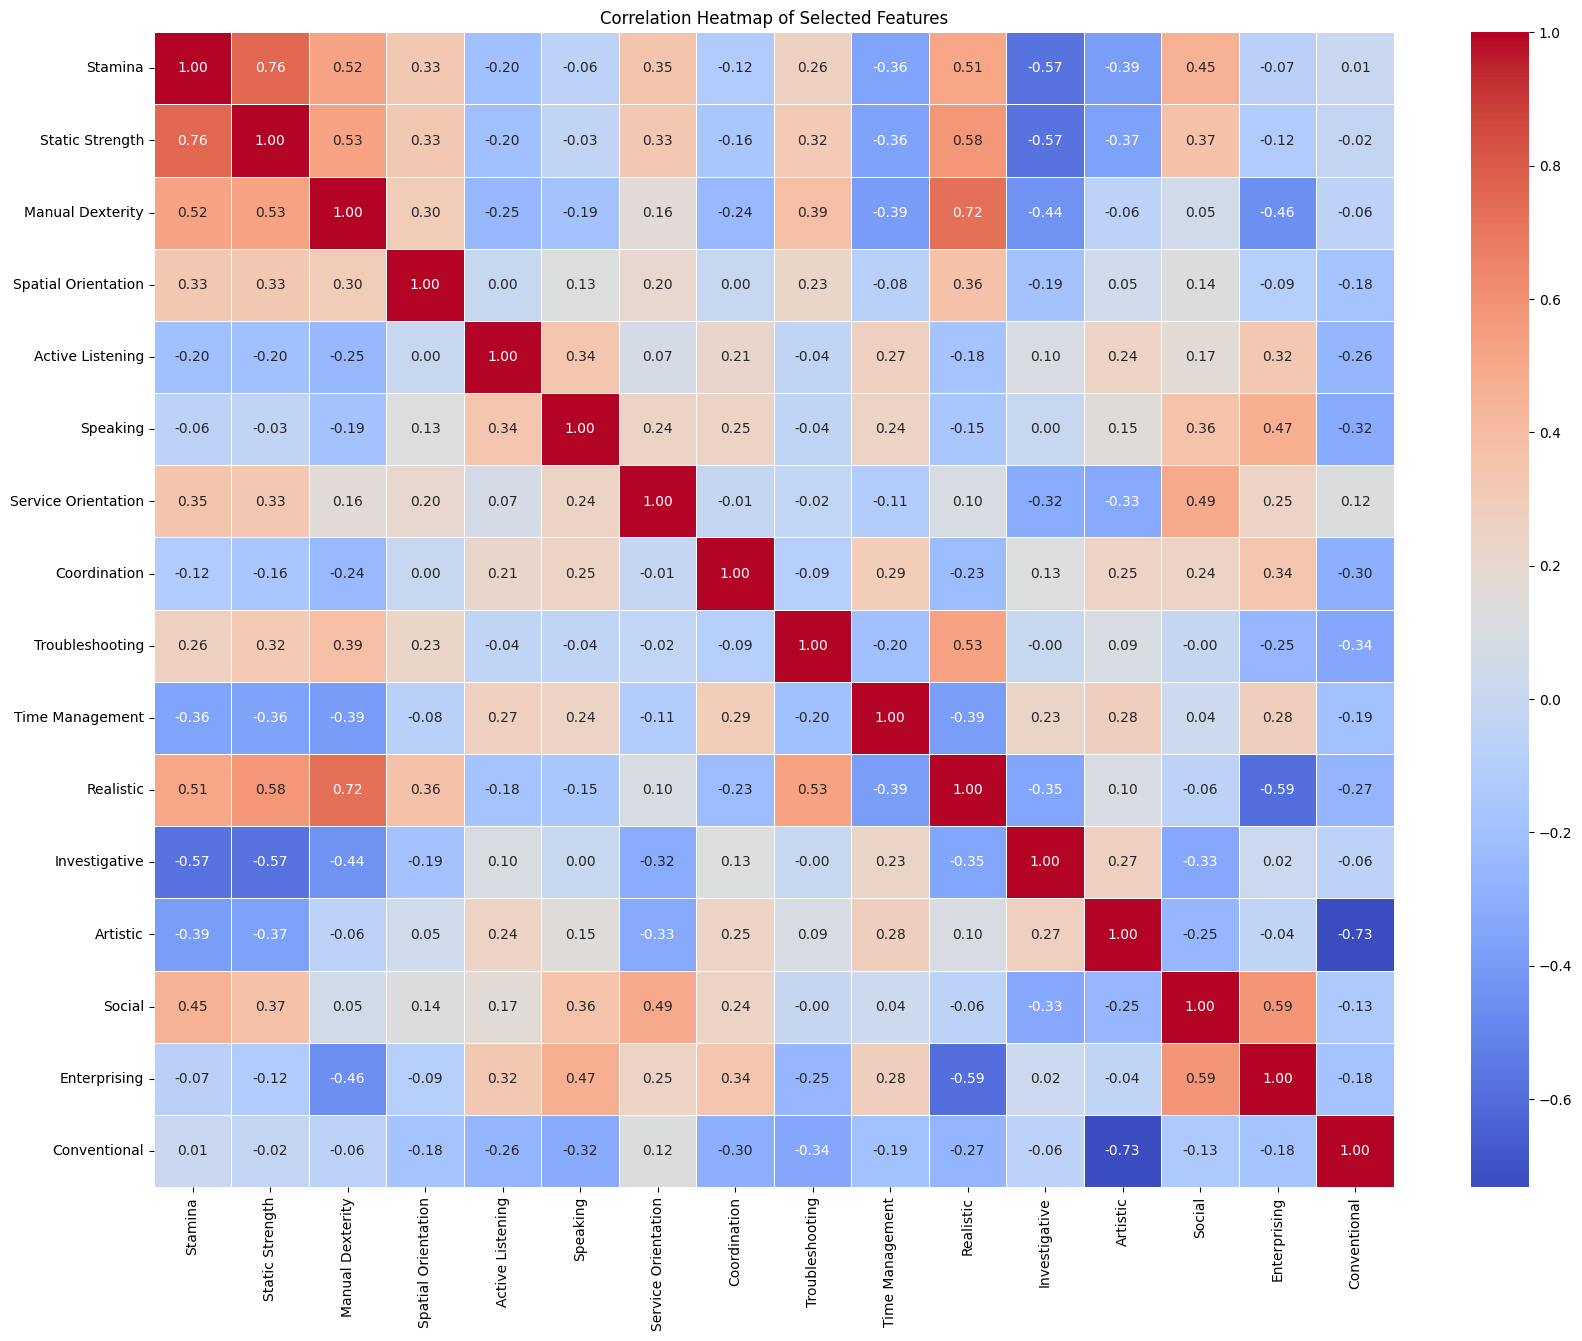

In [10]:
# HEATMAP KORELASI

plt.figure(figsize=(20,15))

# Use 'fitur_15' which contains the selected features
corr_matrix = df_clean[fitur_16].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5,
    annot=True, # Add annotations to show correlation values
    fmt=".2f" # Format annotations to two decimal places
)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

**Tujuan:**
Memahami pola, karakteristik, dan hubungan antarfitur dalam dataset sebelum digunakan untuk pengembangan sistem rekomendasi. EDA juga digunakan untuk menjawab pertanyaan bisnis yang telah dirumuskan sebelumnya.

**Insight Analisis Korelasi (Heatmap):**
- Heatmap korelasi pada 16 fitur terpilih menunjukkan interaksi antar variabel. Tidak ditemukan multikolinearitas yang sangat ekstrem (korelasi > 0.90) antar variabel prediktor, yang berarti ke-16 fitur ini masing-masing membawa informasi yang unik dan independen.
- Fitur-fitur yang berada dalam satu rumpun (misalnya *Active Listening* dan *Speaking* pada kategori komunikasi) menunjukkan korelasi positif yang moderat, yang sejalan dengan ekspektasi logis di dunia kerja nyata.

##**Visualization & Explanatory Analysis**

###Pertanyaan 1:
Bagaimana karakteristik dan distribusi 6 dimensi kepribadian Holland Code (RIASEC) dalam memetakan kecocokan karir pada target profesi di sektor UMKM, operasional, dan digital kreatif?

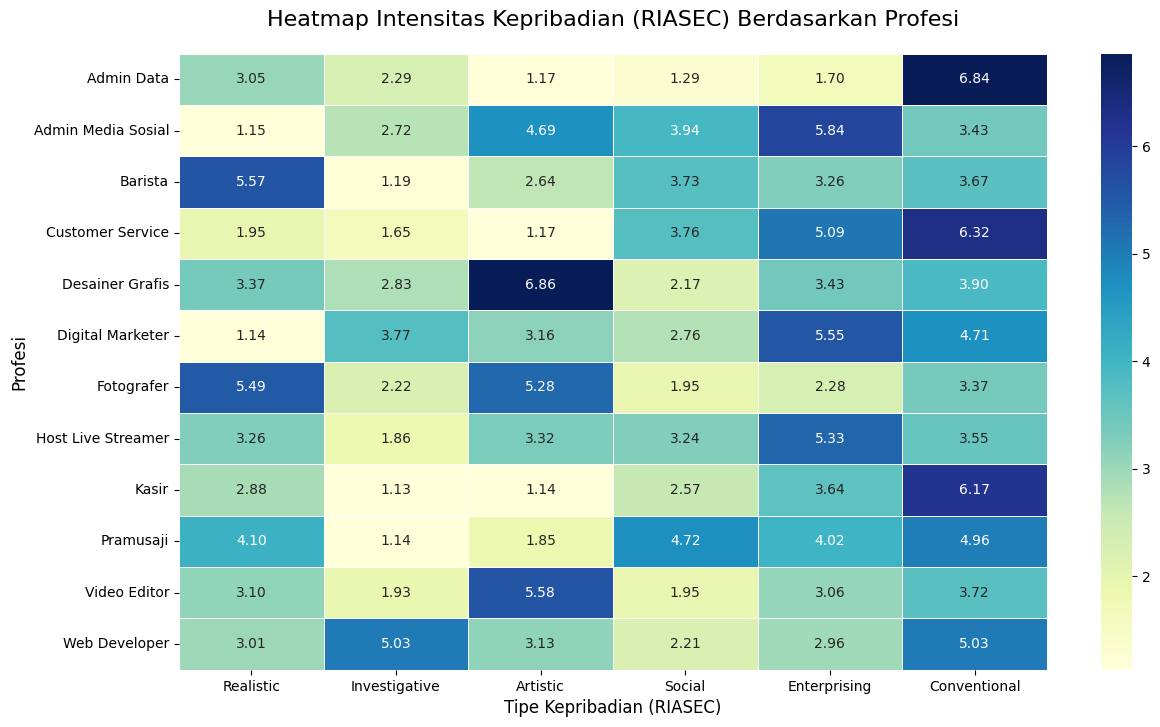

In [11]:
# Visualisasi Profil Kepribadian RIASEC (Menjawab Pertanyaan 1)
plt.figure(figsize=(14, 8))
sns.heatmap(df_riasec_mean, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5)
plt.title('Heatmap Intensitas Kepribadian (RIASEC) Berdasarkan Profesi', fontsize=16, pad=20)
plt.xlabel('Tipe Kepribadian (RIASEC)', fontsize=12)
plt.ylabel('Profesi', fontsize=12)
plt.show()

###Pertanyaan 2:

Dari 10 metrik kompetensi (fisik, komunikasi, dan kognitif) yang diekstraksi, kompetensi apa saja yang paling dominan secara lintas sektoral sehingga krusial untuk dijadikan parameter utama dalam kuesioner asesmen RESTART?



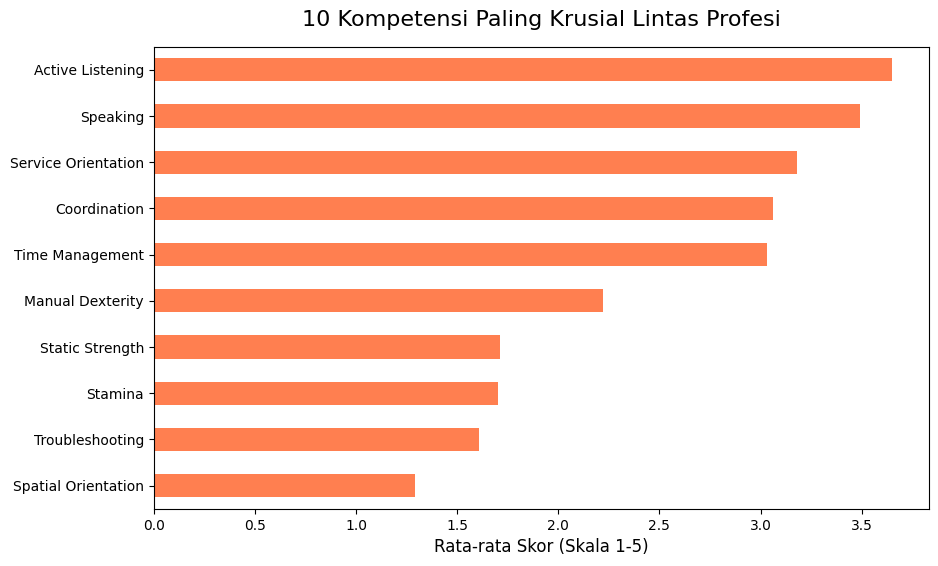

In [12]:
# Visualisasi Top Kompetensi Lintas Sektoral (Menjawab Pertanyaan 2)
plt.figure(figsize=(10, 6))
top_kompetensi.plot(kind='barh', color='coral')
plt.title('10 Kompetensi Paling Krusial Lintas Profesi', fontsize=16, pad=15)
plt.xlabel('Rata-rata Skor (Skala 1-5)', fontsize=12)
plt.gca().invert_yaxis() # Membalik urutan agar nilai tertinggi ada di paling atas
plt.show()

## **Kesimpulan**
- **Pertanyaan 1:** Berdasarkan visualisasi heatmap RIASEC, profesi di sektor operasional (seperti Pramusaji dan Kasir) sangat didominasi oleh profil *Conventional* dan *Social*. Sebaliknya, profesi di sektor kreatif (seperti Video Editor dan Desainer Grafis) menunjukkan lonjakan skor yang tajam pada profil *Artistic*. Tipe *Investigative* rata-rata memiliki skor rendah di sektor UMKM, namun penting dipertahankan untuk menjaga standar validitas asesmen Holland Code.
- **Pertanyaan 2:** Dari 10 metrik kompetensi fisik, komunikasi, dan kognitif yang diekstraksi, kemampuan *Active Listening*, *Speaking*, dan *Service Orientation* secara konsisten muncul sebagai 3 kompetensi (*soft skills*) dengan rata-rata skor tertinggi lintas sektoral. Hal ini memvalidasi bahwa modul komunikasi dan jiwa pelayanan (sosial) adalah indikator yang paling mutlak untuk dijadikan parameter prioritas dalam kuesioner asesmen aplikasi RESTART.

## ***Data Dictionary* (Kamus Data)**
Berikut adalah penjelasan untuk ke-17 kolom yang dipertahankan dalam `Master_Data_RESTART.csv` setelah melalui proses *Feature Selection*:

| Nama Kolom | Kategori | Tipe Data | Rentang Skala | Deskripsi / Definisi |
| :--- | :--- | :--- | :--- | :--- |
| **Target_Profesi** | **Label Target** | Categorical | 15 Jenis | Kelas target yang merepresentasikan profesi di sektor UMKM, operasional, atau digital kreatif. |
| **Stamina** | Kompetensi Fisik | Float | 1.0 - 5.0 | Kemampuan fisik untuk mengerahkan tenaga dalam waktu lama tanpa kelelahan. |
| **Static Strength** | Kompetensi Fisik | Float | 1.0 - 5.0 | Kemampuan menggunakan otot tubuh secara maksimal untuk mengangkat, mendorong, atau menarik beban. |
| **Manual Dexterity** | Kompetensi Fisik | Float | 1.0 - 5.0 | Kecepatan dan ketepatan tangan dalam memanipulasi atau merakit objek. |
| **Spatial Orientation** | Kompetensi Kognitif | Float | 1.0 - 5.0 | Kemampuan memahami dan mengetahui posisi diri terkait ruang dan lingkungan sekitar. |
| **Active Listening** | Kompetensi Sosial | Float | 1.0 - 5.0 | Kemampuan mendengarkan, memahami, dan merespons pembicaraan orang lain secara empatik dan efektif. |
| **Speaking** | Kompetensi Sosial | Float | 1.0 - 5.0 | Kemampuan menyampaikan informasi atau ide secara verbal kepada audiens dengan artikulasi yang jelas. |
| **Service Orientation** | Kompetensi Sosial | Float | 1.0 - 5.0 | Keinginan dan kemampuan proaktif untuk mencari cara dalam membantu pelanggan atau orang lain. |
| **Coordination** | Kompetensi Sosial | Float | 1.0 - 5.0 | Kemampuan menyesuaikan tindakan diri sendiri agar selaras dengan tindakan rekan kerja atau tim. |
| **Troubleshooting** | Kompetensi Teknis | Float | 1.0 - 5.0 | Kemampuan menganalisis penyebab kesalahan operasional dan memutuskan pemecahan masalah yang tepat. |
| **Time Management** | Kompetensi Teknis | Float | 1.0 - 5.0 | Kemampuan mengatur dan memprioritaskan waktu kerja sendiri maupun orang lain secara efisien. |
| **Realistic** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada aktivitas fisik, teknis, atau bekerja menggunakan alat dan mesin secara praktis. |
| **Investigative** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada observasi, riset, pemecahan masalah logis, dan berpikir analitis. |
| **Artistic** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada kreativitas, ruang eksplorasi, serta ekspresi ide visual, desain, atau tulisan. |
| **Social** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada interaksi sosial, mengajar, membantu, dan melakukan pendampingan pada orang lain. |
| **Enterprising** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada aktivitas memimpin, memengaruhi, negosiasi, dan berorientasi pada target bisnis. |
| **Conventional** | Kepribadian (RIASEC) | Float | 1.0 - 7.0 | Tingkat preferensi pada pekerjaan terstruktur, sangat rapi, sistematis, dan berbasis akurasi data. |